# Purpose:
- Running another round of landmark extension.
- Based on the 2nd iteration, where now most of the cells are matched.
    - Use the same logic as the first round - find 5 nearest cells, and choose the one with the highest gene counts
    - Check many-to-one matching


In [1]:
import os
import zarr
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import Rbf
from scipy.spatial import distance_matrix
import cv2
import os
import json
from pathlib import Path

In [ ]:
def get_hcr_data_asset_path(mouse_id, data_path, round=1):
    data_path = Path(data_path)
    HCR_data_assets = [f for f in np.sort(os.listdir(data_path)) if f'HCR_{mouse_id}' in f and 'processed' in f]
    HCR_data_asset = HCR_data_assets[round-1]
    return data_path / HCR_data_asset

def get_hcr_scales(mouse_id, data_path, round=1):
    hcr_data_asset_path = get_hcr_data_asset_path(mouse_id, data_path, round)

    json_file = [hcr_data_asset_path / f for f in os.listdir(hcr_data_asset_path) if f.endswith('_ng.json')][0]
    with open(json_file, 'r') as file:
        data = json.load(file)

    scale_x = data['dimensions']['x'][0]*4e6
    scale_y = data['dimensions']['y'][0]*4e6
    scale_z = data['dimensions']['z'][0]*1e6

    return scale_x, scale_y, scale_z


def get_hcr_centroids_df(mouse_id, code_path, data_path):
    coreg_path = code_path / f'{mouse_id}_coreg'
    fn = coreg_path / f'{mouse_id}_HCR_cell_centroids.csv'
    if not fn.exists():
        fn = code_path / f'{mouse_id}_HCR_cell_centroids.csv'
        assert fn.exists(), f'Centroid file not found: {fn}'
    HCR_cell_centroids_df = pd.read_csv(fn).set_index('hcr_cell_id',drop=True)

    scale_x, scale_y, scale_z = get_hcr_scales(mouse_id, data_path)
    HCR_cell_centroids_df['hcr_x'] = HCR_cell_centroids_df['hcr_x'] * scale_x
    HCR_cell_centroids_df['hcr_y'] = HCR_cell_centroids_df['hcr_y'] * scale_y
    HCR_cell_centroids_df['hcr_z'] = HCR_cell_centroids_df['hcr_z'] * scale_z
    return HCR_cell_centroids_df


def generate_hcr_centroids_df(mouse_id, data_path):
    hcr_data_asset_path = get_hcr_data_asset_path(mouse_id, data_path)

    HCR_cell_centroids = np.load(hcr_data_asset_path / 'cell_body_segmentation/cell_centroids.npy')

    HCR_cell_ids = HCR_cell_centroids[:,3]
    HCR_cell_centroids = HCR_cell_centroids[:,:-1]

    HCR_cell_centroids_df = pd.DataFrame()
    HCR_cell_centroids_df['hcr_cell_id'] = HCR_cell_ids
    HCR_cell_centroids_df['hcr_z'] = HCR_cell_centroids[:,0]
    HCR_cell_centroids_df['hcr_y'] = HCR_cell_centroids[:,1]
    HCR_cell_centroids_df['hcr_x'] = HCR_cell_centroids[:,2]
    HCR_cell_centroids_df.set_index('hcr_cell_id', inplace=True)

    return HCR_cell_centroids_df


def get_ids_from_landmarks(landmarks):
    columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
    assert len(landmarks.columns) == len(columns)
    if not all([a==b for a,b in zip(landmarks.columns, columns)]):
        landmarks.columns = columns
    matched_ids = landmarks['ids'].values
    def _get_ids(x):
        if x.startswith('cz'):
            cz_id = int(x.split('-')[0].split('cz')[-1])
            hcr_id = int(x.split('-')[1].split('hcr')[-1])
            return cz_id, hcr_id
        else:
            return -1
    
    ids = [_get_ids(x) for x in matched_ids]
    ids = [id for id in ids if id != -1]
    zstack_ids = [id[0] for id in ids]
    hcr_ids = [id[1] for id in ids]
    return zstack_ids, hcr_ids

In [4]:
data_path = Path('/root/capsule/data/')
code_path = Path('/root/capsule/code/')
mouse_id = 767018
coreg_path = code_path / f'{mouse_id}_coreg'
hcr_asset_path = get_hcr_data_asset_path(mouse_id, data_path)

# Get HCR centroids, scaled to match with landmarks
HCR_cell_centroids_df = get_hcr_centroids_df(mouse_id, code_path, data_path)

# Get HCR spot counts (only use the first round, channel 488)
# It takes about 10 s
spots_488_file = hcr_asset_path / 'image_spot_detection/channel_488_spots/spots.csv'
spots_488 = pd.read_csv(spots_488_file)

# Get czstack centroids
czstack_centroid_fn = next(code_path.rglob(f'{mouse_id}_czstack_cell_centroids.csv'))
czstack_cell_centroids_df = pd.read_csv(czstack_centroid_fn).set_index('czstack_cell_id',drop=True)
czstack_cell_centroids = np.vstack(czstack_cell_centroids_df[['czstack_z','czstack_y','czstack_x']].values)


In [7]:
# Get landmarks from the previous iteration
# Apply the transformation to the leftover cells
current_iter = 3
prev_iter = current_iter - 1
filter_hcr_rois = True if current_iter == 2 else False

# landmarks_file = next(coreg_path.glob(f'{mouse_id}_landmarks_matched_ext_iter{prev_iter}.csv'))
landmarks_file = next(coreg_path.glob(f'{mouse_id}_landmarks_matched_ext_iter{prev_iter}_reordered_qced.csv'))

landmarks = pd.read_csv(landmarks_file,header=None)
columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
landmarks.columns = columns
landmarks = landmarks.query('active')

points_zstack = landmarks[['czstack_x', 'czstack_y', 'czstack_z']].values.astype(np.float32)
points_HCR = landmarks[['hcr_x', 'hcr_y', 'hcr_z']].values.astype(np.float32)

matched_czstack_ids, matched_hcr_ids = get_ids_from_landmarks(landmarks)
leftover_czstack_ids = list(set(czstack_cell_centroids_df.index) - set(matched_czstack_ids))
leftover_czstack_df = czstack_cell_centroids_df.loc[leftover_czstack_ids]
leftover_czstack_cell_centroids = np.vstack(leftover_czstack_df[['czstack_x','czstack_y','czstack_z']].values)

interp_zstacktoHCR_0 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,0], function='thin_plate')
interp_zstacktoHCR_1 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,1], function='thin_plate')
interp_zstacktoHCR_2 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,2], function='thin_plate')

HCR_centroids_est = np.zeros_like(leftover_czstack_cell_centroids)

HCR_centroids_est[:,0] = interp_zstacktoHCR_0(leftover_czstack_cell_centroids[:, 0], leftover_czstack_cell_centroids[:, 1], leftover_czstack_cell_centroids[:, 2])
HCR_centroids_est[:,1] = interp_zstacktoHCR_1(leftover_czstack_cell_centroids[:, 0], leftover_czstack_cell_centroids[:, 1], leftover_czstack_cell_centroids[:, 2])
HCR_centroids_est[:,2] = interp_zstacktoHCR_2(leftover_czstack_cell_centroids[:, 0], leftover_czstack_cell_centroids[:, 1], leftover_czstack_cell_centroids[:, 2])

print(f'Previously matched cells: {len(matched_czstack_ids)}')
print(f'New estimation: {HCR_centroids_est.shape[0]}')
print(f'{HCR_centroids_est.shape[0] / (len(matched_czstack_ids) + HCR_centroids_est.shape[0]) * 100:.1f}% of total czstack cells have been matched after {current_iter} iterations')

Previously matched cells: 561
New estimation: 224
28.5% of total czstack cells have been matched after 3 iterations


## Where are the leftover centroids?

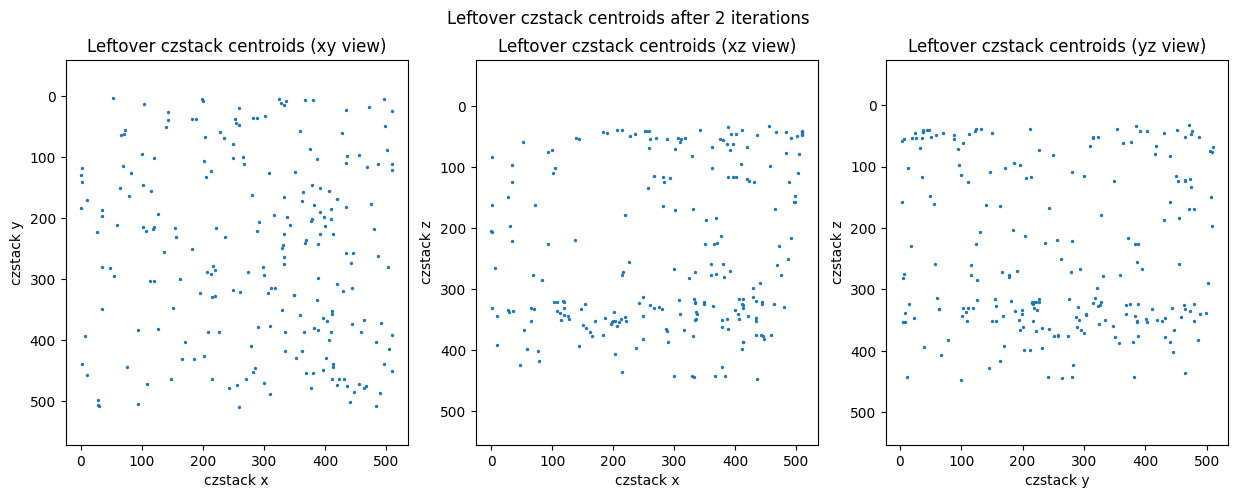

In [8]:
# plot density of leftover czstack centroids from 3 different views
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].scatter(leftover_czstack_cell_centroids[:,0], leftover_czstack_cell_centroids[:,1], s=2)
axs[0].set_xlabel('czstack x')
axs[0].set_ylabel('czstack y')
axs[0].set_title('Leftover czstack centroids (xy view)')
axs[1].scatter(leftover_czstack_cell_centroids[:,0], leftover_czstack_cell_centroids[:,2], s=2)
axs[1].set_xlabel('czstack x')
axs[1].set_ylabel('czstack z')
axs[1].set_title('Leftover czstack centroids (xz view)')
axs[2].scatter(leftover_czstack_cell_centroids[:,1], leftover_czstack_cell_centroids[:,2], s=2)
axs[2].set_xlabel('czstack y')
axs[2].set_ylabel('czstack z')
axs[2].set_title('Leftover czstack centroids (yz view)')
for ax in axs:
    # make the origin at the upper left corner
    ax.invert_yaxis()
    ax.axis('equal')
fig.suptitle(f'Leftover czstack centroids after {prev_iter} iterations')
plt.show()

This shows that the leftover after the 2nd iteration is not only at the edges

In [70]:
# process spot counts df

spot_488_counts = pd.DataFrame(spots_488['SEG_ID'].value_counts())
spot_488_bounding_box_min = spots_488.groupby('SEG_ID').agg({'X':'min','Y':'min','Z':'min'}).rename(columns={'X':'min_x','Y':'min_y','Z':'min_z'})
spot_488_bounding_box_max = spots_488.groupby('SEG_ID').agg({'X':'max','Y':'max','Z':'max'}).rename(columns={'X':'max_x','Y':'max_y','Z':'max_z'})
spot_488_bounding_box = pd.concat([spot_488_bounding_box_min, spot_488_bounding_box_max], axis=1)
spot_488_bounding_box['bb_volume'] = (spot_488_bounding_box['max_x'] - spot_488_bounding_box['min_x'] + 1) * (spot_488_bounding_box['max_y'] - spot_488_bounding_box['min_y'] + 1) * (spot_488_bounding_box['max_z'] - spot_488_bounding_box['min_z'] + 1)
spot_488_counts = spot_488_counts.merge(spot_488_bounding_box[['bb_volume']], left_index=True, right_index=True)

spot_488_counts['density'] = spot_488_counts['count'] / spot_488_counts['bb_volume']
matched_spot_counts = spot_488_counts.loc[matched_hcr_ids]
nonmatched_spot_counts = spot_488_counts.drop(index=matched_hcr_ids)

Text(0.5, 0.98, '767018 HCR 488 spot density after 2 iterations (cells with >80 spots)')

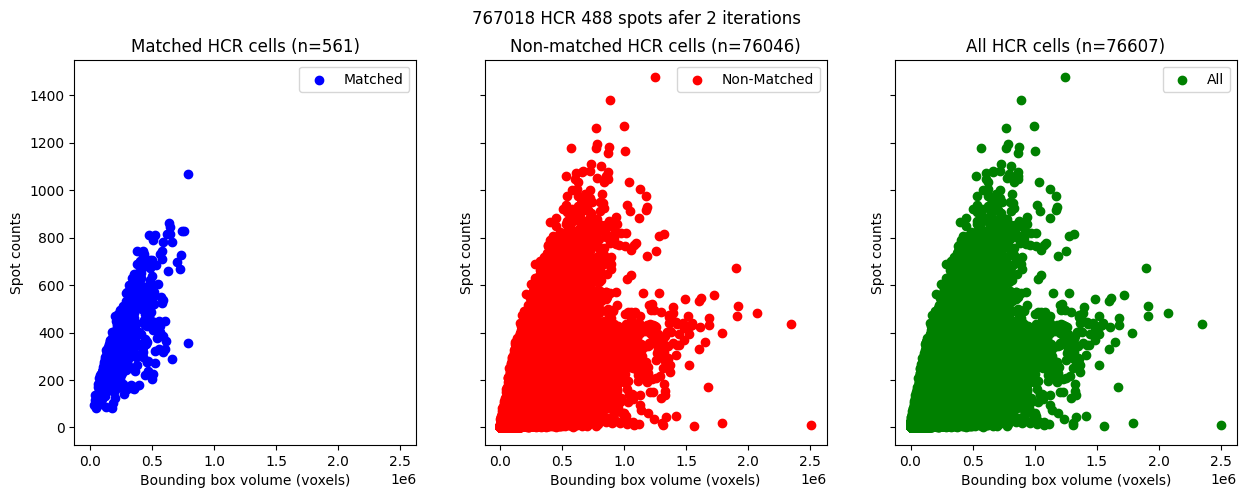

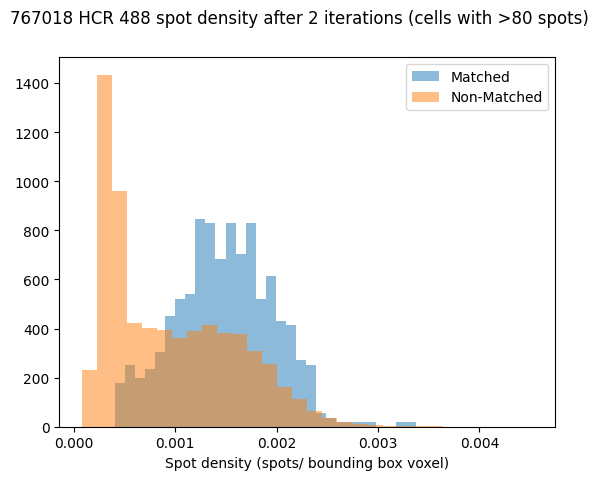

In [71]:
# Show some plots

fig, ax = plt.subplots(1, 3, figsize=(15,5), sharex=True, sharey=True)
ax[0].scatter(matched_spot_counts['bb_volume'], matched_spot_counts['count'], color='blue', label='Matched')
ax[1].scatter(nonmatched_spot_counts['bb_volume'], nonmatched_spot_counts['count'], color='red', label='Non-Matched')
ax[2].scatter(spot_488_counts['bb_volume'], spot_488_counts['count'], color='green', label='All')
for a in ax:
    a.set_xlabel('Bounding box volume (voxels)')
    a.set_ylabel('Spot counts')
    a.legend()
ax[0].set_title(f'Matched HCR cells (n={len(matched_spot_counts)})')
ax[1].set_title(f'Non-matched HCR cells (n={len(nonmatched_spot_counts)})')
ax[2].set_title(f'All HCR cells (n={len(spot_488_counts)})')
fig.suptitle(f'{mouse_id} HCR 488 spots afer {prev_iter} iterations')

fig, ax = plt.subplots()

ax.hist(matched_spot_counts.query('count>80')['density'], bins=30, alpha=0.5, label='Matched', density=True)
ax.hist(nonmatched_spot_counts.query('count>80')['density'], bins=30, alpha=0.5, label='Non-Matched', density=True)
ax.set_xlabel('Spot density (spots/ bounding box voxel)')
ax.legend()
fig.suptitle(f'{mouse_id} HCR 488 spot density after {prev_iter} iterations (cells with >80 spots)')

In [72]:
print(f'Minimum spot counts from matched HCR IDs: {matched_spot_counts["count"].min()}')
print(f'Minimum bounding box volume from matched HCR IDs: {matched_spot_counts["bb_volume"].min()}')
print(f'Maximum bounding box volume from matched HCR IDs: {matched_spot_counts["bb_volume"].max()}')
print(f'Minimum density from matched HCR IDs: {matched_spot_counts["density"].min()}')

Minimum spot counts from matched HCR IDs: 82
Minimum bounding box volume from matched HCR IDs: 28980
Maximum bounding box volume from matched HCR IDs: 792528
Minimum density from matched HCR IDs: 0.0004082286080204915


In [73]:
if filter_hcr_rois:
    min_counts_threshold = matched_spot_counts['count'].min() * 0.9
    min_density_threshold = matched_spot_counts['density'].min() * 0.9
    leftover_spot_counts = nonmatched_spot_counts.query('count >= @min_counts_threshold and density >= @min_density_threshold')
else:
    leftover_spot_counts = nonmatched_spot_counts
leftover_HCR_df = pd.merge(leftover_spot_counts, HCR_cell_centroids_df, left_index=True, right_index=True, how='inner')


In [74]:
# One-to-One Matching Algorithm
# Solves the many-to-one problem by iteratively assigning best matches

def one_to_one_matching(HCR_centroids_est, leftover_HCR_df):
    """
    Solve one-to-one matching from distance matrix.
    
    Parameters:
    -----------
    HCR_centroids_est : ndarray of shape (M, 3)
        Estimated HCR centroids from leftover czstack centroids
    leftover_HCR_df : DataFrame of shape (N, 3)
        DataFrame containing leftover HCR centroids with columns ['hcr_x', 'hcr_y', 'hcr_z']
    
    Returns:
    --------
    matched_indices : ndarray of shape (M,)
        Index of matched target point for each source point (-1 if unmatched)
    matched_distances : ndarray of shape (M,)
        Distance to matched target point for each source point (inf if unmatched)
    dist_matrix : ndarray of shape (M, N)
        Pairwise distance matrix between source and target points
    """
    dist_matrix = distance_matrix(HCR_centroids_est, leftover_HCR_df[['hcr_x','hcr_y','hcr_z']].values)
    M, N = dist_matrix.shape
    
    # Initialize output arrays
    matched_indices = np.full(M, -1, dtype=int)
    matched_distances = np.full(M, np.inf)
    
    # Keep track of which target points are already assigned
    used_targets = np.zeros(N, dtype=bool)
    
    # Create a copy of distance matrix that we can modify
    working_dist_matrix = dist_matrix.copy()
    
    # Process matches iteratively
    for iteration in range(min(M, N)):
        # Find the global minimum in the remaining matrix
        flat_idx = np.argmin(working_dist_matrix)
        source_idx, target_idx = np.unravel_index(flat_idx, working_dist_matrix.shape)
        
        # Record this match
        matched_indices[source_idx] = target_idx
        matched_distances[source_idx] = working_dist_matrix[source_idx, target_idx]
        
        # Mark this target as used
        used_targets[target_idx] = True
        
        # Remove this source row and target column from consideration
        working_dist_matrix[source_idx, :] = np.inf
        working_dist_matrix[:, target_idx] = np.inf
    
    return matched_indices, matched_distances, dist_matrix



In [75]:
def choose_max_count_nearest_neighbor(HCR_centroids_est, leftover_HCR_df, k=5, resolve_duplicates=True):
    """ Choose nearest neighbor with maximum spot counts among k nearest candidates.
    If resolve_duplicates is True, attempt to resolve many-to-one matches by reassigning duplicates

    Parameters:
    -----------
    HCR_centroids_est : ndarray of shape (M, 3)
        Estimated HCR centroids from leftover czstack centroids
    leftover_HCR_df : DataFrame of shape (N, 3)
        DataFrame containing leftover HCR centroids with columns ['hcr_x', 'hcr_y', 'hcr_z']
    k : int
        Number of nearest neighbors to consider
    resolve_duplicates : bool
        Whether to attempt to resolve many-to-one matches
    Returns:
    --------
    chosen_indices : ndarray of shape (M,)
        Index of matched target point for each source point (-1 if unmatched)
    chosen_distances : ndarray of shape (M,)
        Distance to matched target point for each source point (inf if unmatched)
    dist_matrix : ndarray of shape (M, N)
        Pairwise distance matrix between source and target points
    """
    hcr_centroids = leftover_HCR_df[['hcr_x','hcr_y','hcr_z']].to_numpy()
    counts = leftover_HCR_df['count'].to_numpy()

    dist_matrix = distance_matrix(HCR_centroids_est, hcr_centroids)
    k = min(k, dist_matrix.shape[1])

    # Indices of k smallest distances per source (row)
    nearest_indices = np.argpartition(dist_matrix, k, axis=1)[:, :k]
    nearest_distances = np.take_along_axis(dist_matrix, nearest_indices, axis=1)

    # Counts for those candidates
    nearest_counts = counts[nearest_indices]

    # Pick candidate with max counts per row
    best_local_idx = np.argmax(nearest_counts, axis=1)
    row_idx = np.arange(nearest_indices.shape[0])
    chosen_indices = nearest_indices[row_idx, best_local_idx]
    chosen_distances = nearest_distances[row_idx, best_local_idx]

    # Detect many-to-one
    # targets mapped multiple times
    _, inverse, counts_per_target = np.unique(chosen_indices, return_inverse=True, return_counts=True)
    duplicate_sources_mask = counts_per_target[inverse] > 1

    if resolve_duplicates and duplicate_sources_mask.any():
        # Keep only the source with minimal distance for each duplicated target
        # For duplicates: build per-target minimal distance
        keep_mask = np.ones_like(chosen_indices, dtype=bool)
        dup_targets = np.unique(chosen_indices[duplicate_sources_mask])
        for t in dup_targets:
            sel = np.where(chosen_indices == t)[0]
            best = sel[np.argmin(chosen_distances[sel])]
            sel_remove = sel[sel != best]
            keep_mask[sel_remove] = False

        # Optionally attempt second-best for removed rows (still within their k candidates)
        removed_rows = np.where(~keep_mask)[0]
        if len(removed_rows):
            # For each removed row choose next best (by counts) that is not already taken
            taken = set(chosen_indices[keep_mask])
            # Mask out previously chosen best
            nearest_counts_removed = nearest_counts[removed_rows].copy()
            nearest_counts_removed[np.arange(len(removed_rows)), best_local_idx[removed_rows]] = -1
            # Iterate only over removed rows (small set)
            for j, r in enumerate(removed_rows):
                # Sort candidates by counts descending
                cand_order = np.argsort(-nearest_counts_removed[j])
                for cand_pos in cand_order:
                    cand_target = nearest_indices[r, cand_pos]
                    if cand_target not in taken:
                        chosen_indices[r] = cand_target
                        chosen_distances[r] = nearest_distances[r, cand_pos]
                        taken.add(cand_target)
                        break
                else:
                    # Could not find alternative unique target; mark unmatched
                    chosen_indices[r] = -1
                    chosen_distances[r] = np.inf

    return chosen_indices, chosen_distances, dist_matrix

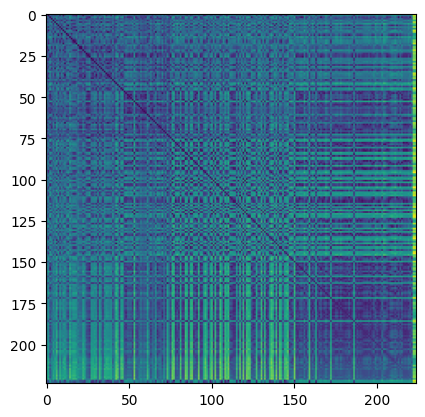

In [76]:
if filter_hcr_rois:
    final_matched_indices, final_matched_distances, dist_matrix = \
        one_to_one_matching(HCR_centroids_est, leftover_HCR_df)
else:
    final_matched_indices, final_matched_distances, dist_matrix = \
        choose_max_count_nearest_neighbor(HCR_centroids_est, leftover_HCR_df, k=5, resolve_duplicates=True)

sort_order = np.argsort(final_matched_distances)
    
# Create matrix with matched sources (rows) and their assigned targets (columns)
sorted_sources = np.arange(len(final_matched_indices))[sort_order]
sorted_targets = final_matched_indices[sort_order]
sorted_dists = final_matched_distances[sort_order]

# Extract relevant distances for visualization
matched_dist_matrix = dist_matrix[np.ix_(sorted_sources, sorted_targets)]

plt.imshow(matched_dist_matrix)



In [77]:
# assign matching to matched_cells_df
new_matched_hcr_df = leftover_HCR_df.iloc[final_matched_indices].reset_index().copy().rename(columns={'index':'hcr_cell_id'})
new_matched_hcr_df['distance'] = final_matched_distances
new_matched_hcr_df['czstack_cell_id'] = leftover_czstack_ids
new_matched_hcr_df['czstack_x'] = leftover_czstack_df['czstack_x'].values
new_matched_hcr_df['czstack_y'] = leftover_czstack_df['czstack_y'].values
new_matched_hcr_df['czstack_z'] = leftover_czstack_df['czstack_z'].values
new_matched_hcr_df.sort_values(by='distance', inplace=True)
new_matched_hcr_df.head()


,hcr_cell_id,count,bb_volume,density,hcr_z,hcr_y,hcr_x,distance,czstack_cell_id,czstack_x,czstack_y,czstack_z
205,43757,71,215946,0.000329,781.0,856.311659,945.099734,2.519296,365,300.778947,471.236842,169.500877
161,22386,46,198000,0.000232,578.0,1362.403688,814.877224,4.172535,248,487.488546,111.375000,124.553785
80,102764,159,224826,0.000707,1231.0,1442.312956,874.069274,4.404908,674,428.426422,61.203573,313.717442
214,65359,405,230996,0.001753,942.0,1029.941673,711.291136,4.767652,443,491.237113,372.082474,215.731959
202,36336,73,164000,0.000445,712.0,1365.363291,1361.417154,5.391669,350,71.870370,56.064815,161.740741


In [78]:
landmarks

,ids,active,czstack_x,czstack_y,czstack_z,hcr_x,hcr_y,hcr_z
4,Pt-806,True,65.988776,116.591277,274.363539,1328.934343,1289.424264,1117.212415
6,Pt-808,True,391.852482,151.214172,45.605979,932.275504,1324.427081,297.656733
12,Pt-816,True,483.479430,403.515004,44.274563,797.209641,945.554563,305.925948
13,Pt-817,True,455.503668,472.383220,32.569388,812.626915,870.173731,321.899945
18,cz0002-hcr9906,True,263.569199,461.115564,34.607875,994.426443,858.284728,358.000000
...,...,...,...,...,...,...,...,...
692,cz0676-hcr103596,True,359.416497,146.206721,312.518669,945.099734,1315.050048,1239.000000
693,cz0677-hcr105352,True,135.873409,183.008944,315.384245,1223.302370,1214.423563,1260.000000
694,cz0678-hcr102360,True,475.766031,205.534564,315.363779,782.321596,1240.073451,1227.000000
698,cz0682-hcr104705,True,101.245107,259.910142,316.977758,1240.073451,1113.797077,1252.000000


In [79]:
save_fn = coreg_path / f'{mouse_id}_landmarks_matched_ext_iter{current_iter}.csv'
assert not save_fn.exists(), f'File already exists: {save_fn}'
landmarks_ext = pd.DataFrame()

landmarks_ext[0] = ['cz'+str(int(new_matched_hcr_df['czstack_cell_id'].iloc[i]))+'-hcr'+str(int(new_matched_hcr_df['hcr_cell_id'].iloc[i])) for i in range(len(new_matched_hcr_df))]

landmarks_ext[1] = False
landmarks_ext[2] = new_matched_hcr_df['czstack_x'].values
landmarks_ext[3] = new_matched_hcr_df['czstack_y'].values
landmarks_ext[4] = new_matched_hcr_df['czstack_z'].values
landmarks_ext[5] = new_matched_hcr_df['hcr_x'].values
landmarks_ext[6] = new_matched_hcr_df['hcr_y'].values
landmarks_ext[7] = new_matched_hcr_df['hcr_z'].values

columns = np.arange(8)
landmarks.columns = columns
landmarks_ext = pd.concat([landmarks_ext, landmarks])

landmarks_ext.to_csv(save_fn, index=False, header=False)
landmarks_ext.head()

,0,1,2,3,4,5,6,7
0,cz365-hcr43757,False,300.778947,471.236842,169.500877,945.099734,856.311659,781.0
1,cz248-hcr22386,False,487.488546,111.375000,124.553785,814.877224,1362.403688,578.0
2,cz674-hcr102764,False,428.426422,61.203573,313.717442,874.069274,1442.312956,1231.0
3,cz443-hcr65359,False,491.237113,372.082474,215.731959,711.291136,1029.941673,942.0
4,cz350-hcr36336,False,71.870370,56.064815,161.740741,1361.417154,1365.363291,712.0


In [80]:
def _get_hcr_id(x):
    if x.startswith('cz'):
        return int(x.split('-hcr')[-1])
    else:
        return -1
landmarks_ext['hcr_id'] = landmarks_ext[0].apply(_get_hcr_id)

In [81]:
pd.DataFrame(landmarks_ext.query('hcr_id != -1').hcr_id.value_counts()).query('count == 2')

,count
hcr_id,
108313,2
